# Group surface maps for Fig. 2

Averages the surface-sampled nPRF parameters across all subjects on fsaverage
(median for preferred numerosity, mean for R²), plus the proportion of subjects
with cvR² > 0 per vertex, and writes the group GIfTIs
(`group_{par}_hemi-{L,R}.pars.gii`) that `visualize_group.py` renders (Fig. 2a).
Requires `sample_prf_to_surface_nilearn.py` outputs for every subject.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns

from neural_priors.utils.data import get_all_subject_ids, Subject
from tqdm.contrib.itertools import product
from itertools import product as product_
import nibabel as nb
import numpy as np

pars = []

subjects = get_all_subject_ids()
model_labels = [0, 4, 15, 31]
model_labels = [3]

keys = list(product_(get_all_subject_ids(), model_labels))

for subject, model_label in product(get_all_subject_ids(), model_labels):
    sub = Subject(subject)

    pars.append(sub.get_prf_parameters_surf(model_label=model_label, smoothed=True, space='fsaverage'))


pars = pd.concat(pars, keys=keys, names=['subject', 'model_label'])


  0%|          | 0/39 [00:00<?, ?it/s]

# mean pars

In [2]:
for p in ['r2', 'mu.narrow', 'mu.wide']:

    
    if p.startswith('mu'):
        mean_ = pars[p].groupby(['model_label', 'hemi', 'vertex']).median()
    else:
        mean_ = pars[p].groupby(['model_label', 'hemi', 'vertex']).mean()

    for (model_label, hemi), m in mean_.groupby(['model_label', 'hemi']):
        fn = Path(f'/data/ds-neuralpriors/derivatives/encoding_models/model{model_label}.whole_brain.smoothed/group_{p}_hemi-{hemi}.pars.gii')

        im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(m.values)])
        nb.save(im, fn)

In [5]:
pars['cvr2>0.0'] = pars['cvr2'] > 0.0

# Proportion of cvR2 > 0.0

In [6]:
prop_cvr2 = pars['cvr2>0.0'].unstack(['hemi', 'vertex']).groupby(['model_label']).mean() 


for model_label, prop in prop_cvr2.iterrows():
    for hemi, p in prop.groupby('hemi'):
        fn = Path(f'/data/ds-neuralpriors/derivatives/encoding_models/model{model_label}.whole_brain.smoothed/group_cvr2_count_hemi-{hemi}.pars.gii')
        im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(p.values.astype(np.float32))])
        nb.save(im, fn)

# Colorbar

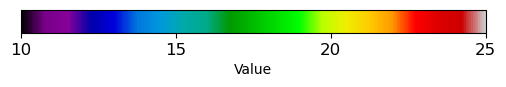

In [ ]:
# Make a colorbar for nipy_spectral from 10 to 25 using imshow

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
cmap = mpl.colormaps['nipy_spectral']
norm = mpl.colors.Normalize(vmin=10, vmax=25)

fig, ax = plt.subplots(figsize=(6, .3))
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation ='horizontal')
cb.set_label('Value')   
cb.set_ticks([10, 15, 20, 25])
# cb.set_ticklabels([f'{x:.1f}' for x in np.linspace(10, 25, 8)])
cb.ax.tick_params(labelsize=12)

